<div style="color: hotpink; font-size: 40px; font-family: Times; font-weight: bold;">
Finite State Machine Generator</div>

<div style="background-color: #f3e5ff; padding: 12px; border-radius: 10px; font-size: 16px; font-family: Times;">
This notebook will show how to build a 3-state Finite State Machine.</div>

<div style="background-color: #ffe6f2; padding: 12px; border-radius: 10px; font-size: 20px; font-weight: bold; font-family: Times;">
Step 1: Download the logictools Overlay
</div> 

In [1]:
from pynq.overlays.logictools import LogicToolsOverlay

logictools_olay = LogicToolsOverlay('logictools.bit')

<div style="background-color: #ffe6f2; padding: 12px; border-radius: 10px; font-size: 20px; font-weight: bold; font-family: Times;">
Step 2: Specify the Finite State Machine
</div> 

In [2]:
fsm_spec = {
    'inputs': [('reset', 'D0'), ('x', 'D1')],
    'outputs': [('bit2', 'D3'), ('bit1', 'D4'), ('bit0', 'D5')],
    'states': ['S0', 'S1', 'S2'],
    'transitions': [
        ['00', 'S0', 'S0', '001'],
        ['01', 'S0', 'S1', '001'],
        
        ['00', 'S1', 'S1', '010'],
        ['01', 'S1', 'S2', '010'],
        
        ['00', 'S2', 'S2', '100'],
        ['01', 'S2', 'S0', '100'],
        
        ['1-', '*', 'S0', '']
    ]
}

<div style="background-color: #ffe3f9; padding: 12px; border-radius: 10px; font-size: 16px; font-family: Times;">
<ul>
    <li><b>reset</b> is assigned to <b>D0</b>.</li>
    <li><b>x</b> is assigned to <b>D1</b>.</li>
    <li>the outputs <b>bit2</b>, <b>bit1</b>, and <b>bit0</b> represent the 3-bit state value</li>
    <li>the FSM starts in <b>S0</b> whenever reset is asserted</li>
    <li>when <b>x = 0</b>, the FSM stays in the same state</li>
    <li>when <b>x = 1</b>, the FSM advances to the next state in the cycle
        <b>S0 → S1 → S2 → S0</b>
    </li>
</ul></div> 

<div style="background-color: #ffe6f2; padding: 12px; border-radius: 10px; font-size: 20px; font-weight: bold; font-family: Times;">
Step 3: Instantiate the FSM Generator Object
</div> 

In [3]:
fsm_generator = logictools_olay.fsm_generator

<div style="background-color: #ffe6f2; padding: 12px; border-radius: 10px; font-size: 20px; font-weight: bold; font-family: Times;">
Step 4: Set Up the Trace Analyzer
</div> 

In [4]:
fsm_generator.trace()

<div style="background-color: #ffe6f2; padding: 12px; border-radius: 10px; font-size: 20px; font-weight: bold; font-family: Times;">
Step 5: Set Up the FSM Generator & Show Diagram
</div> 

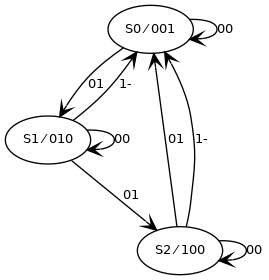

In [5]:
fsm_generator.setup(fsm_spec)
fsm_generator.show_state_diagram()

<div style="background-color: #ffe3f9; padding: 12px; border-radius: 10px; font-size: 16px; font-family: Times;">

<ul> <li><b>reset (D0):</b></li></ul>
<ul><ul><ul><li>connect to <b>GND</b> for normal operation</li></ul></ul></ul>
<ul><ul><ul> <li>connect to <b>3.3V</b> to reset the FSM back to <b>S0</b></li></ul></ul></ul>

 
<ul> <li><b>x (D1):</b></li></ul>
<ul><ul><ul> <li>connect to <b>GND</b> for <b>x = 0</b> → hold current state</li></ul></ul></ul>
<ul><ul><ul> <li>connect to <b>3.3V</b> for <b>x = 1</b> → advance to the next state</li></ul></ul></ul>


    
</div> 

<div style="background-color: #ffe6f2; padding: 12px; border-radius: 10px; font-size: 20px; font-weight: bold; font-family: Times;">
Step 6: Run & Display Waveform
</div> 

In [6]:
fsm_generator.run()
fsm_generator.show_waveform()

<div style="background-color: #ffe6f2; padding: 12px; border-radius: 10px; font-size: 20px; font-weight: bold; font-family: Times;">
Step 7: Verify with Verification Table
</div> 

<div style="background-color: #ffe3f9; padding: 12px; border-radius: 10px; font-size: 16px; font-family: Times;">


<table style="border-collapse: collapse; width: 100%; text-align: center;">

<tr>
    <th style="border: 1px solid black; padding: 8px;">Current State</th>
    <th style="border: 1px solid black; padding: 8px;">Input x</th>
    <th style="border: 1px solid black; padding: 8px;">Next State</th>
    <th style="border: 1px solid black; padding: 8px;">Output</th>
    <th style="border: 1px solid black; padding: 8px;">Action</th>
</tr>

<tr>
    <td style="border: 1px solid black; padding: 8px;">S0</td>
    <td style="border: 1px solid black; padding: 8px;">0</td>
    <td style="border: 1px solid black; padding: 8px;">S0</td>
    <td style="border: 1px solid black; padding: 8px;">001</td>
    <td style="border: 1px solid black; padding: 8px;">Hold</td>
</tr>

<tr>
    <td style="border: 1px solid black; padding: 8px;">S0</td>
    <td style="border: 1px solid black; padding: 8px;">1</td>
    <td style="border: 1px solid black; padding: 8px;">S1</td>
    <td style="border: 1px solid black; padding: 8px;">001</td>
    <td style="border: 1px solid black; padding: 8px;">Advance</td>
</tr>

<tr>
    <td style="border: 1px solid black; padding: 8px;">S1</td>
    <td style="border: 1px solid black; padding: 8px;">0</td>
    <td style="border: 1px solid black; padding: 8px;">S1</td>
    <td style="border: 1px solid black; padding: 8px;">010</td>
    <td style="border: 1px solid black; padding: 8px;">Hold</td>
</tr>

<tr>
    <td style="border: 1px solid black; padding: 8px;">S1</td>
    <td style="border: 1px solid black; padding: 8px;">1</td>
    <td style="border: 1px solid black; padding: 8px;">S2</td>
    <td style="border: 1px solid black; padding: 8px;">010</td>
    <td style="border: 1px solid black; padding: 8px;">Advance</td>
</tr>

<tr>
    <td style="border: 1px solid black; padding: 8px;">S2</td>
    <td style="border: 1px solid black; padding: 8px;">0</td>
    <td style="border: 1px solid black; padding: 8px;">S2</td>
    <td style="border: 1px solid black; padding: 8px;">100</td>
    <td style="border: 1px solid black; padding: 8px;">Hold</td>
</tr>

<tr>
    <td style="border: 1px solid black; padding: 8px;">S2</td>
    <td style="border: 1px solid black; padding: 8px;">1</td>
    <td style="border: 1px solid black; padding: 8px;">S0</td>
    <td style="border: 1px solid black; padding: 8px;">100</td>
    <td style="border: 1px solid black; padding: 8px;">Advance</td>
</tr>

</table>

</div>

<div style="background-color: #ffe6f2; padding: 12px; border-radius: 10px; font-size: 20px; font-weight: bold; font-family: Times;">
Step 8: Stop the FSM Generator
</div> 

In [7]:
fsm_generator.stop()